In [ ]:
import torch 
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 【显卡点火核心】：检测你的电脑是否有 N 卡，有就直接接管！
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 当前核动力引擎: {device}")

df = pd.read_csv(r'D:\PycharmWork\pythonProject\IEEE33_50000_Safe_Final.csv')
raw_data = df.values
m = raw_data.shape[0]
print(raw_data.shape)
data_3d = raw_data.reshape(m , 33, 4)
print(data_3d.shape)
X_3d = data_3d[:,:,0:2]
Y_3d = data_3d[:,:,2:4]
print(X_3d.shape)
print(Y_3d.shape)
X_3d = X_3d.reshape(m , 66)
Y_3d = Y_3d.reshape(m , 66)
print(X_3d.shape)
print(Y_3d.shape)
ssl = StandardScaler()
X_3d = ssl.fit_transform(X_3d)

# 【改动 1】：把 5 万发洗净的弹药，直接装填进显卡的显存里！
X = torch.tensor(X_3d , dtype = torch.float32).to(device)
Y = torch.tensor(Y_3d , dtype = torch.float32).to(device)
loss_list = []

# 【改动 2】：手工捏造的权重 W 和偏置 b，也必须直接在显卡上铸造！
W = (torch.randn((66,66) , dtype = torch.float32).to(device)) * 0.01
b = torch.zeros((1 , 66) , dtype = torch.float32).to(device)
learning_rate = 0.01
m = X.shape[0]
for epoch in range(50000):
    y_pred = torch.matmul(X, W) + b
    error = y_pred - Y
    loss = torch.mean((y_pred - Y)**2)
    loss_list.append(loss.item()) 
    
    dW = (2 / m) *torch.matmul(X.T, error)
    db = (2 / m) *torch.sum(error , dim = 0)
    W = W - learning_rate * dW
    b = b - learning_rate * db
# 设置 300 DPI 高清与学术字体风格
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.sans-serif'] = ['SimHei'] # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
plt.plot(loss_list, color='red', linewidth=1.5)
plt.title("手工微积分引擎：IEEE 33节点电压预测误差收敛图", fontweight='bold')
plt.xlabel("训练轮次 (Epochs)")
plt.ylabel("均方误差 (MSE Loss)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import torch 
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader,random_split
import torch.nn as nn
class MyDataset(Dataset):
    def __init__(self , features , labels):
        self.features = features
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, index):
        return self.features[index], self.labels[index]
# 【显卡点火核心】：检测你的电脑是否有 N 卡，有就直接接管！
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 当前核动力引擎: {device}")

df = pd.read_csv(r'D:\PycharmWork\pythonProject\IEEE33_50000_Safe_Final.csv')
raw_data = df.values
m = raw_data.shape[0]
print(raw_data.shape)
data_3d = raw_data.reshape(m , 33, 4)
print(data_3d.shape)
X_3d = data_3d[:,:,0:2]
Y_3d = data_3d[:,:,2:4]
print(X_3d.shape)
print(Y_3d.shape)
X_3d = X_3d.reshape(m , 66)
Y_3d = Y_3d.reshape(m , 66)
print(X_3d.shape)
print(Y_3d.shape)
ssl = StandardScaler()
X_3d = ssl.fit_transform(X_3d)
#现在开始投毒
noise = np.random.normal(loc = 0. , scale = 1. , size = X_3d.shape )
X_3d_dirty = X_3d + noise
# 【改动 1】：把 5 万发洗净的弹药，直接装填进显卡的显存里！
X = torch.tensor(X_3d_dirty , dtype = torch.float32).to(device)
Y = torch.tensor(Y_3d , dtype = torch.float32).to(device)
loss_list = []

# # 【改动 2】：手工捏造的权重 W 和偏置 b，也必须直接在显卡上铸造！
# W = (torch.randn((66,66) , dtype = torch.float32).to(device)) * 0.01
# b = torch.zeros((1 , 66) , dtype = torch.float32).to(device)
grid_data = MyDataset(X, Y)
train_loader = DataLoader(dataset=grid_data, batch_size=1000, shuffle=True)
for batch_X , batch_Y in train_loader:
    print(batch_X.shape)
    print(batch_Y.shape)
    break
total_count = len(grid_data)
train_count = int(total_count * 0.8)
val_count = int(total_count * 0.1)
test_count = total_count - train_count - val_count
train_db , val_db , test_db = random_split(grid_data , [train_count , val_count , test_count])
train_loader = DataLoader(dataset=train_db, batch_size=1000, shuffle=True)
val_loader = DataLoader(dataset=val_db, batch_size=1000, shuffle=False)
test_loader = DataLoader(dataset=test_db, batch_size=1000, shuffle=False)
#model更新 加入dropout 随机击毙神经元
class PowerMLP(nn.Module):
    def __init__(self):
        super(PowerMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features = 66 , out_features = 128),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            nn.Linear(64,66),
        )
    def forward(self , x):
        return self.net(x)
#手写PINN
class PowerPINNLoss(nn.Module):
    def __init__(self):
        super(PowerPINNLoss, self).__init__()
        self.loss = nn.MSELoss()
    def forward(self , pred, target):
        data_loss = self.loss(pred, target)
        pred_3d = pred.reshape(-1 , 33 ,2)
        Vm_pred = pred_3d[: , : , 0]
        penalty_low = torch.mean(torch.relu(0.9 - Vm_pred))
        penalty_high = torch.mean(torch.relu(Vm_pred - 1.1))
        return data_loss + 10 * penalty_low + 10 * penalty_high
model = PowerMLP().to(device)
print(model)
# criterion = nn.MSELoss() 现在开始用powerpinnloss
criterion = PowerPINNLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 150
train_loss_list = []
val_loss_list = []
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for v_X , v_Y in val_loader:
            v_outputs = model(v_X)
            loss = criterion(v_outputs, v_Y)
            total_val_loss += loss.item()
    avg_train = total_train_loss / len(train_loader)
    avg_val = total_val_loss / len(val_loader)
    
    train_loss_list.append(avg_train)
    val_loss_list.append(avg_val)
    if (epoch + 1) % 10 == 0:
        print(f"   ➤ 第 {epoch+1:3d} 圈 | 训练误差: {avg_train:.6f} | 验证误差: {avg_val:.6f}")
        plt.figure(figsize=(8, 5))
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.sans-serif'] = ['SimHei'] # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
# 画出两条线，对比看是否过拟合
plt.plot(train_loss_list, color='red', linewidth=1.5, label='训练误差 (Train)')
plt.plot(val_loss_list, color='blue', linestyle='--', linewidth=1.5, label='验证误差 (Val)')

# 标题升级：我们已经是多层感知机了！
plt.title("深度学习 MLP 引擎：IEEE 33节点电压预测收敛图", fontweight='bold')
plt.xlabel("训练轮次 (Epochs)")
plt.ylabel("均方误差 (MSE Loss)")
plt.legend() # 显示图例
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
#开始大调查
model.eval()
low_violations_count = 0
high_violations_count = 0
total_bus = 0
with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        t_output = model(batch_X)
        pred_3d = t_output.reshape(-1 , 33 ,2)
        Vm_pred = pred_3d[: , : , 0]
        low_violations_count += torch.sum(Vm_pred<0.9).item()
        high_violations_count += torch.sum(Vm_pred>1.1).item()
        total_bus += Vm_pred.numel()
print(f'总共测试节点{total_bus} ， 有多少超出 低：{low_violations_count} , 高：{high_violations_count}')

In [ ]:
import torch 
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader,random_split
import torch.nn as nn
class MyDataset(Dataset):
    def __init__(self , features , labels):
        self.features = features
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, index):
        return self.features[index], self.labels[index]
# 【显卡点火核心】：检测你的电脑是否有 N 卡，有就直接接管！
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 当前核动力引擎: {device}")

df = pd.read_csv(r'D:\PycharmWork\pythonProject\IEEE33_50000_Safe_Final.csv')
raw_data = df.values
m = raw_data.shape[0]
print(raw_data.shape)
data_3d = raw_data.reshape(m , 33, 4)
print(data_3d.shape)
X_3d = data_3d[:,:,0:2]
Y_3d = data_3d[:,:,2:4]
print(X_3d.shape)
print(Y_3d.shape)
X_3d = X_3d.reshape(m , 66)
Y_3d = Y_3d.reshape(m , 66)
print(X_3d.shape)
print(Y_3d.shape)
ssl = StandardScaler()
X_3d = ssl.fit_transform(X_3d)
#现在开始投毒
noise = np.random.normal(loc = 0. , scale = 1. , size = X_3d.shape )
X_3d_dirty= X_3d + noise
# 【改动 1】：把 5 万发洗净的弹药，直接装填进显卡的显存里！
X = torch.tensor(X_3d_dirty , dtype = torch.float32).to(device)
Y = torch.tensor(Y_3d , dtype = torch.float32).to(device)
loss_list = []

# # 【改动 2】：手工捏造的权重 W 和偏置 b，也必须直接在显卡上铸造！
# W = (torch.randn((66,66) , dtype = torch.float32).to(device)) * 0.01
# b = torch.zeros((1 , 66) , dtype = torch.float32).to(device)
grid_data = MyDataset(X, Y)
train_loader = DataLoader(dataset=grid_data, batch_size=1000, shuffle=True)
for batch_X , batch_Y in train_loader:
    print(batch_X.shape)
    print(batch_Y.shape)
    break
total_count = len(grid_data)
train_count = int(total_count * 0.8)
val_count = int(total_count * 0.1)
test_count = total_count - train_count - val_count
train_db , val_db , test_db = random_split(grid_data , [train_count , val_count , test_count])
train_loader = DataLoader(dataset=train_db, batch_size=1000, shuffle=True)
val_loader = DataLoader(dataset=val_db, batch_size=1000, shuffle=False)
test_loader = DataLoader(dataset=test_db, batch_size=1000, shuffle=False)
#model更新 加入dropout 随机击毙神经元
class PowerMLP(nn.Module):
    def __init__(self):
        super(PowerMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features = 66 , out_features = 128),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            nn.Linear(64,66),
        )
    def forward(self , x):
        return self.net(x)
#手写PINN
class PowerPINNLoss(nn.Module):
    def __init__(self):
        super(PowerPINNLoss, self).__init__()
        self.loss = nn.MSELoss()
    def forward(self , pred, target):
        data_loss = self.loss(pred, target)
        pred_3d = pred.reshape(-1 , 33 ,2)
        Vm_pred = pred_3d[: , : , 0]
        penalty_low = torch.mean(torch.relu(0.9 - Vm_pred))
        penalty_high = torch.mean(torch.relu(Vm_pred - 1.1))
        return data_loss + 10 * penalty_low + 10 * penalty_high
model = PowerMLP().to(device)
print(model)
#对比PINN
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 150
train_loss_list = []
val_loss_list = []
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for v_X , v_Y in val_loader:
            v_outputs = model(v_X)
            loss = criterion(v_outputs, v_Y)
            total_val_loss += loss.item()
    avg_train = total_train_loss / len(train_loader)
    avg_val = total_val_loss / len(val_loader)
    
    train_loss_list.append(avg_train)
    val_loss_list.append(avg_val)
    if (epoch + 1) % 10 == 0:
        print(f"   ➤ 第 {epoch+1:3d} 圈 | 训练误差: {avg_train:.6f} | 验证误差: {avg_val:.6f}")
        plt.figure(figsize=(8, 5))
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.sans-serif'] = ['SimHei'] # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
# 画出两条线，对比看是否过拟合
plt.plot(train_loss_list, color='red', linewidth=1.5, label='训练误差 (Train)')
plt.plot(val_loss_list, color='blue', linestyle='--', linewidth=1.5, label='验证误差 (Val)')

# 标题升级：我们已经是多层感知机了！
plt.title("深度学习 MLP 引擎：IEEE 33节点电压预测收敛图", fontweight='bold')
plt.xlabel("训练轮次 (Epochs)")
plt.ylabel("均方误差 (MSE Loss)")
plt.legend() # 显示图例
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
#开始大调查
model.eval()
low_violations_count = 0
high_violations_count = 0
total_bus = 0
with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        t_output = model(batch_X)
        pred_3d = t_output.reshape(-1 , 33 , 2)
        Vm_pred = pred_3d[: , : ,0]
        low_violations_count += torch.sum(Vm_pred<0.9).item()
        high_violations_count += torch.sum(Vm_pred>1.1).item()
        total_bus += Vm_pred.numel()
print(f'总共测试节点{total_bus} ， 有多少超出 低：{low_violations_count} , 高：{high_violations_count}')

In [18]:
import torch 
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader,random_split
import torch.nn as nn
# IEEE 33 节点系统的支路数据 (共 32 条支路)
# 格式: [起点(From), 终点(To), 电阻 R (p.u.), 电抗 X (p.u.)]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前炼丹炉核心算力来源: {device}")
branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])
R = branch_data[: , 2]
X = branch_data[: , 3]
num_nodes =33
y_bus = np.zeros((num_nodes , num_nodes) , dtype = complex)
print(y_bus)
for i in range(len(branch_data)):
    f = int(branch_data[i , 0]-1)
    t = int(branch_data[i , 1]-1)
    r = branch_data[i , 2]
    x = branch_data[i , 3]
    #开始算电导
    z_line = r + 1j * x
    y_line = 1 / z_line
    #主对角线 就是自导
    y_bus[f,f] += y_line
    y_bus[t,t] += y_line
    #非对角线 就是互导
    y_bus[f , t] = -y_line
    y_bus[t , f] = -y_line
# #开始做PINN预测
# G= y_bus.real
# B = y_bus.imag
# V = np.ones(33)
# theta = np.zeros(33)
# P_calc = np.zeros(33)
# for i in range(33):
#     P_sum = 0
#     for j in range(33):
#         theta_ij = theta[i] - theta[j]
#         term = G[i , j]*np.cos(theta_ij) + B[i , j]*np.sin(theta_ij)
#         P_sum += V[j] * term
#     P_calc[i] = P_sum * V[i]
G_tensor = torch.tensor(y_bus.real , dtype = torch.float32).to(device)
B_tensor = torch.tensor(y_bus.imag , dtype = torch.float32).to(device)
# def calculate_physics_p_torch(V_pred , theta_pred , G_tensor, B_tensor):
#     P_calc = torch.zeros(1 , 33 , dtype=torch.float32 , device=V_pred.device)
#     V_flat = V_pred.squeeze()
#     theta_flat = theta_pred.squeeze()
#     for i in range(33):
#         P_sum = 0
#         for j in range(33):
#             theta_ij = theta_flat[i] - theta_flat[j]
#             term = G_tensor[i , j] * torch.cos(theta_ij) + B_tensor[i,j] * torch.sin(theta_ij)
#             P_sum += V_flat[j] * term
#         P_calc[0 , i] = P_sum * V_flat[i]
#     return P_calc 换GPU！！！
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    """
    向量化物理引擎：彻底消灭 for 循环，让 4060 满血复活！
    """
    # 1. 构造角度差矩阵 theta_ij (33x33)
    # 利用广播机制：(33, 1) - (1, 33) 得到 (33, 33) 的所有差值组合
    delta_theta = theta_pred.reshape(-1, 1) - theta_pred.reshape(1, -1)
    
    # 2. 一次性算出所有括号里的 term (33x33)
    # 这一步直接在显卡里并行炸开！
    cos_matrix = torch.cos(delta_theta)
    sin_matrix = torch.sin(delta_theta)
    term_matrix = G_t * cos_matrix + B_t * sin_matrix
    
    # 3. 算求和项 Sum = V_j * term
    # 这是一个矩阵乘以向量的操作
    # V_pred.reshape(1, -1) 是所有邻居的电压
    sum_part = torch.sum(V_pred * term_matrix, dim=1) 
    
    # 4. 最后乘上自己的电压 V_i
    P_calc = V_pred * sum_part
    
    return P_calc.reshape(1, 33)
class PowerGridPINN(nn.Module):
    def __init__(self , input_dim):
        super(PowerGridPINN, self).__init__()
        
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim , 128),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            nn.Linear(128, 128),
        )
        self.output_layers = nn.Linear(128 , 66)
    def forward(self , x):
        features = self.hidden_layers(x)
        output = self.output_layers(features)
        Vm_pred = output[: , :33]
        theta_pred = output[: ,33:]
        return Vm_pred, theta_pred
class PowerPINNLoss(nn.Module):
    def __init__(self , G , B):
        super(PowerPINNLoss, self).__init__()
        self.G = G
        self.B = B
        self.mse_tool = nn.MSELoss()
    def forward(self, V_pred , theta_pred , P_real_target):
        P_calc = calculate_physics_p_torch(V_pred , theta_pred , self.G , self.B)
        data_loss = self.mse_tool(P_calc , P_real_target)
        penalty_low = torch.mean(torch.relu(0.95 - V_pred))
        penalty_high = torch.mean(torch.relu(V_pred - 1.05))
        return data_loss + 10*(penalty_low + penalty_high)
class MyDataset(Dataset):
    def __init__(self,features , labels):
        self.features = features
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]
df = pd.read_csv(r'D:\PycharmWork\pythonProject\IEEE33_50000_Safe_Final.csv')
raw_data = df.values
m = raw_data.reshape[0]
data_3d = raw_data[m , 33 , 4]
X_3d = data_3d[: , : , 0:2]
Y_3d = data_3d[: , : , 2:]
P_real_pu = data_3d[: , : , 0].copy()
X_3d = X_3d.reshape(m , 66)
Y_3d = Y_3d.reshape(m , 66)
ssl = StandardScaler()
X_3d = ssl.fit_transform(X_3d)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_tensor = torch.tensor(X_3d, dtype=torch.float32).to(device)
P_target_tensor = torch.tensor(P_real_pu, dtype=torch.float32).to(device)
train_dataset = MyDataset(X_tensor, P_target_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# 1. 请出 AI 选手
model = PowerGridPINN(input_dim= 66).to(device)
#2. 误差
pinn_loss = PowerPINNLoss(G_tensor , B_tensor)
#3. 优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
dummy_input = torch.randn(1, 66).to(device)
P_real_target = torch.full((1,33) , 0.5 , dtype=torch.float32).to(device)
for epoch in range(500):
    optimizer.zero_grad()
    V_guess , theta_guess = model(dummy_input)
    loss = pinn_loss(V_guess , theta_guess,  P_real_target)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"第 {epoch} 轮 | 总误差 Loss: {loss.item():.6f}")

🚀 当前炼丹炉核心算力来源: cuda
[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
第 0 轮 | 总误差 Loss: 43.814960
第 10 轮 | 总误差 Loss: 15.752928
第 20 轮 | 总误差 Loss: 9.850753
第 30 轮 | 总误差 Loss: 9.806726
第 40 轮 | 总误差 Loss: 9.670570
第 50 轮 | 总误差 Loss: 9.496265
第 60 轮 | 总误差 Loss: 9.392297
第 70 轮 | 总误差 Loss: 9.311621
第 80 轮 | 总误差 Loss: 9.325612
第 90 轮 | 总误差 Loss: 9.302509
第 100 轮 | 总误差 Loss: 9.191066
第 110 轮 | 总误差 Loss: 9.311327
第 120 轮 | 总误差 Loss: 9.116385
第 130 轮 | 总误差 Loss: 9.181435
第 140 轮 | 总误差 Loss: 9.072503
第 150 轮 | 总误差 Loss: 8.991784
第 160 轮 | 总误差 Loss: 9.055398
第 170 轮 | 总误差 Loss: 9.030516
第 180 轮 | 总误差 Loss: 8.923097
第 190 轮 | 总误差 Loss: 8.922066
第 200 轮 | 总误差 Loss: 8.963015
第 210 轮 | 总误差 Loss: 8.929300
第 220 轮 | 总误差 Loss: 8.753330
第 230 轮 | 总误差 Loss: 9.

🚀 当前炼丹炉核心算力来源: cuda
Epoch 0 | Avg Loss: 66114.021385 | LR: 0.001
Epoch 10 | Avg Loss: 828.196358 | LR: 0.001
Epoch 20 | Avg Loss: 765.890668 | LR: 0.001
Epoch 30 | Avg Loss: 781.551066 | LR: 0.001
Epoch 40 | Avg Loss: 716.046572 | LR: 0.0005
Epoch 50 | Avg Loss: 4379.357317 | LR: 0.0005
Epoch 60 | Avg Loss: 1103.716415 | LR: 0.0005
Epoch 70 | Avg Loss: 1105.418996 | LR: 0.0005
Epoch 80 | Avg Loss: 1079.107444 | LR: 0.00025
Epoch 90 | Avg Loss: 1081.759409 | LR: 0.00025
Epoch 100 | Avg Loss: 1080.718047 | LR: 0.00025
Epoch 110 | Avg Loss: 1081.588678 | LR: 0.00025
Epoch 120 | Avg Loss: 1073.230546 | LR: 0.000125
Epoch 130 | Avg Loss: 1073.535496 | LR: 0.000125
Epoch 140 | Avg Loss: 1073.618535 | LR: 0.000125
📊 全网电压最大误差: 0.041991 p.u.
📊 全网电压平均误差: 0.005090 p.u.
🏆 卧槽！平均误差小于 0.05，你已经成功造出了一个高精度电网 AI 替身！


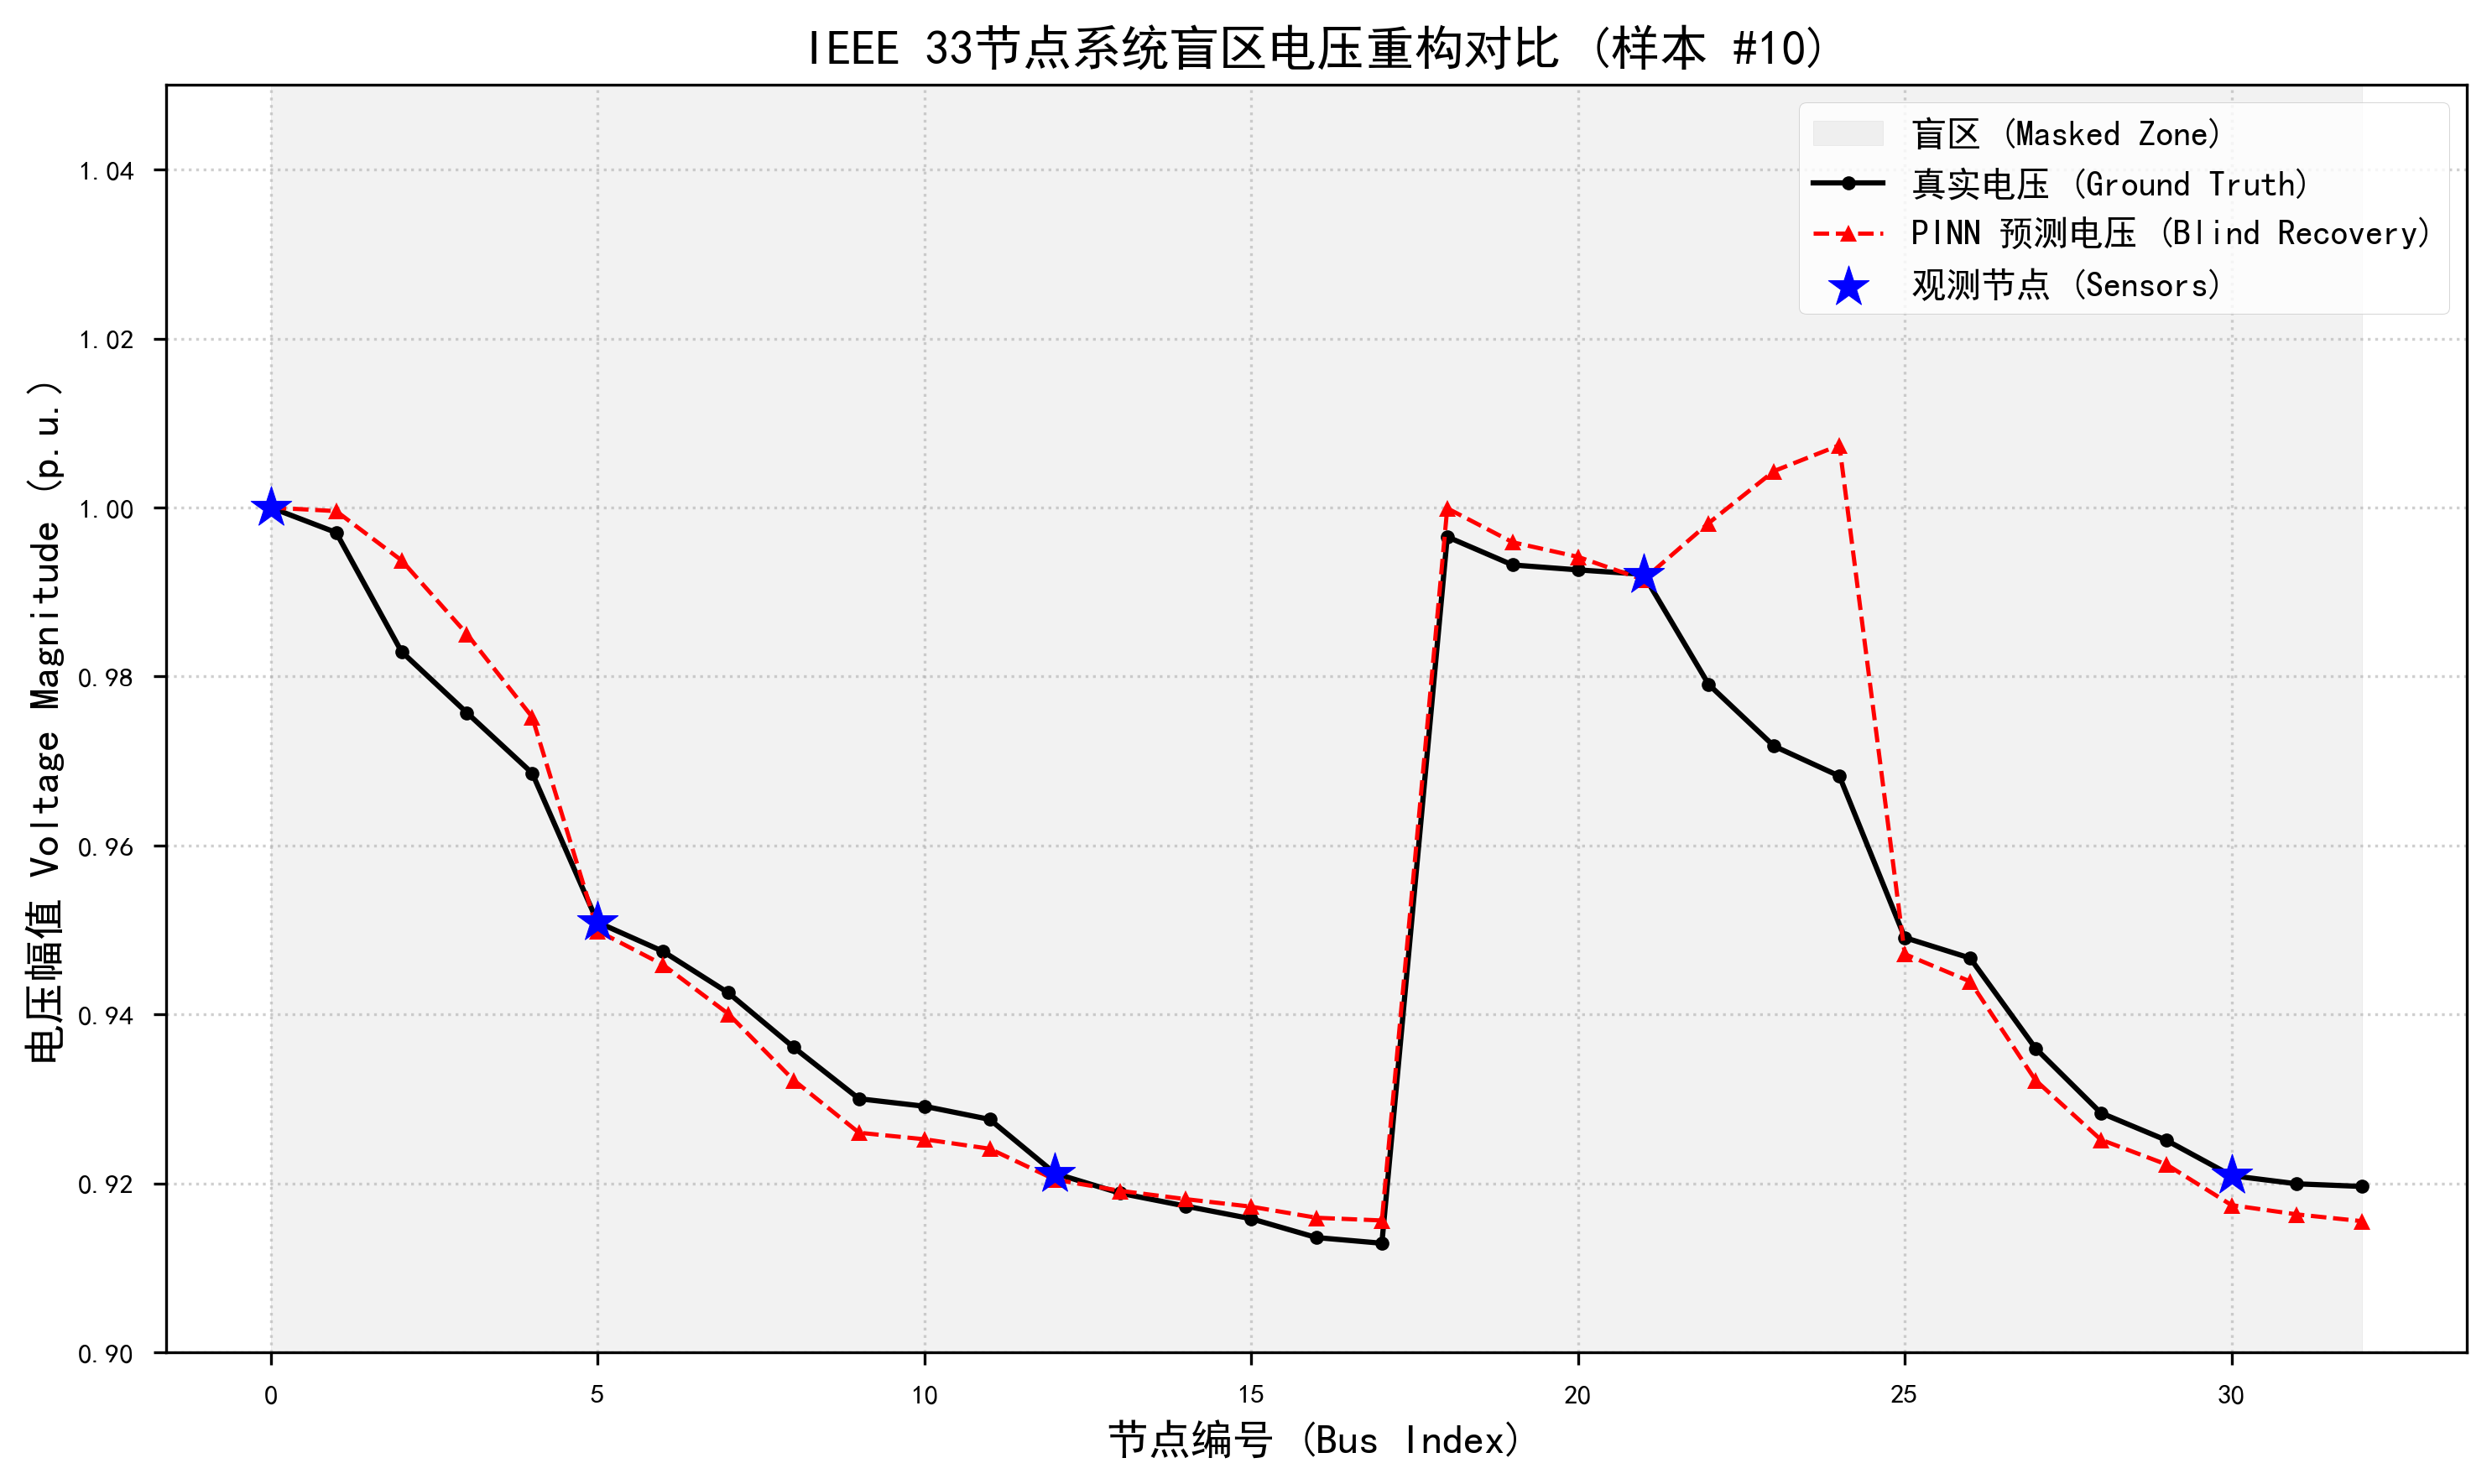


节点    | 真实值 (Actual) | 预测值 (Pred)   | 偏差 (Bias)
-------------------------------------------------------
0  ★ | 1.000000 | 1.000000 | +0.000000
1     | 0.997044 | 0.999577 | +0.002533
2     | 0.982948 | 0.993750 | +0.010802
3     | 0.975715 | 0.985033 | +0.009318
4     | 0.968559 | 0.975195 | +0.006637
5  ★ | 0.950914 | 0.949905 | -0.001009
6     | 0.947471 | 0.945889 | -0.001582
7     | 0.942562 | 0.940078 | -0.002484
8     | 0.936108 | 0.932224 | -0.003885
9     | 0.930026 | 0.926004 | -0.004022
10    | 0.929137 | 0.925230 | -0.003907
11    | 0.927582 | 0.924108 | -0.003474
12 ★ | 0.921186 | 0.920452 | -0.000734
13    | 0.918840 | 0.919123 | +0.000283
14    | 0.917316 | 0.918143 | +0.000827
15    | 0.915827 | 0.917253 | +0.001426
16    | 0.913596 | 0.915940 | +0.002344
17    | 0.912923 | 0.915620 | +0.002697
18    | 0.996535 | 0.999910 | +0.003375
19    | 0.993205 | 0.995891 | +0.002686
20    | 0.992621 | 0.994166 | +0.001545
21 ★ | 0.992102 | 0.991470 | -0.000631
22    | 0.979060 | 

In [45]:
#干净版本
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 环境配置
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前炼丹炉核心算力来源: {device}")

# ==========================================
# 2. 物理网络拓扑 (IEEE 33 节点)
# ==========================================
branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])

R = branch_data[:, 2]
X = branch_data[:, 3]
num_nodes = 33
y_bus = np.zeros((num_nodes, num_nodes), dtype=complex)

for i in range(len(branch_data)):
    f = int(branch_data[i, 0] - 1)
    t = int(branch_data[i, 1] - 1)
    r = branch_data[i, 2]
    x = branch_data[i, 3]
    
    z_line = r + 1j * x
    y_line = 1 / z_line
    y_bus[f, f] += y_line
    y_bus[t, t] += y_line
    y_bus[f, t] = -y_line
    y_bus[t, f] = -y_line

G_tensor = torch.tensor(y_bus.real, dtype=torch.float32).to(device)
B_tensor = torch.tensor(y_bus.imag, dtype=torch.float32).to(device)

# ==========================================
# 3. 核心函数与类定义
# ==========================================
obs_indices = [0,5,12,21,30]
def apply_blind_zone(batch_x ,obs_indices , mean_t , scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[: , idx] = batch_x[: , idx]
        masked_x[:, idx + 33] = batch_x[:, idx + 33]
    return masked_x
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_matrix = torch.cos(delta_theta)
    sin_matrix = torch.sin(delta_theta)
    p_term = G_t * cos_matrix + B_t * sin_matrix
    q_term = G_t * sin_matrix - B_t * cos_matrix
    sum_p = torch.sum(V_pred.unsqueeze(1) * p_term, dim=2)
    sum_q = torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)
    P_calc = V_pred * sum_p
    Q_calc = V_pred * sum_q
    return P_calc, Q_calc
    return P_calc # 这里的形状已经是 [batch_size, 33]，完美对齐 batch_p
class PowerGridPINN(nn.Module):
    def __init__(self, input_dim):
        super(PowerGridPINN, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.SiLU(),
            # nn.Dropout(p=0.2),对物理约束来说 不要击毙神经元!!
            nn.Linear(256, 256),
            nn.SiLU(),
            # nn.Dropout(p=0.2),
            nn.Linear(256, 256),
        )
        self.output_layers = nn.Linear(256, 66)

    def forward(self, x):
        features = self.hidden_layers(x)
        output = self.output_layers(features)
        #来个标准值 残差学习
        Vm_pred = output[:, :33] * 0.1+ 1.0
        theta_pred = output[:, 33:] * 0.01+ 0.0
        Vm_pred[: , 0] = 1.0
        theta_pred[: , 0] = 0.0
        return Vm_pred, theta_pred

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B , obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G = G
        self.B = B
        self.mse_tool = nn.MSELoss()
        self.obs_idx = obs_idx

    def forward(self, V_pred, theta_pred, P_real_target , Q_real_target , V_real , p_weight):
        P_calc , Q_calc= calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        P_loss = self.mse_tool(P_calc, P_real_target)
        Q_loss = self.mse_tool(Q_calc, Q_real_target)
        V_obs_pred = V_pred[: , self.obs_idx]
        V_obs_real = V_real[: , self.obs_idx]
        obs_loss = torch.sum((V_obs_pred - V_obs_real)**2)
        #放宽了物理限制
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.1)
        #但是约束要增高!
        return (
            p_weight * (P_loss + Q_loss) + 
            1000 * torch.mean(penalty_low + penalty_high) + 
            500000 * obs_loss
        )

class MyDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# ==========================================
# 4. 数据读取与预处理
# ==========================================
df = pd.read_csv(r'D:\PycharmWork\pythonProject\IEEE33_50000_Safe_Final.csv')
raw_data = df.values
m = raw_data.shape[0]

data_3d = raw_data.reshape(m, 33, 4)
X_3d = data_3d[:, :, 0:2]
Y_3d = data_3d[:, :, 2:]
P_real_pu = data_3d[:, :, 0].copy() / 100.0
Q_real_pu = data_3d[:, :, 1].copy() / 100.0
X_3d = X_3d.reshape(m, 66)
Y_3d = Y_3d.reshape(m, 66)
ssl = StandardScaler()
X_3d = ssl.fit_transform(X_3d)
mean_tensor = torch.tensor(ssl.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(ssl.scale_, dtype=torch.float32).to(device)
V_real_pu = data_3d[: , : , 2].copy()
PQV_target_up = np.concatenate([P_real_pu, Q_real_pu , V_real_pu], axis=1)
X_tensor = torch.tensor(X_3d, dtype=torch.float32).to(device)
PQ_target_tensor = torch.tensor(PQV_target_up,dtype=torch.float32).to(device)

train_dataset = MyDataset(X_tensor, PQ_target_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# ==========================================
# 5. 模型实例化与训练循环
# ==========================================
# 1. 请出 AI 选手
max_epoch = 150
model = PowerGridPINN(input_dim=66).to(device)
# 在 model = PowerGridPINN(...).to(device) 后面加上
with torch.no_grad():
    # 让前 33 个输出（Vm）的初始偏置变成负数（比如 -0.5）
    # 这样 Vm = (-0.5 * 0.1) + 1.0 = 0.95，AI 一睁眼就在跌落区！
    model.output_layers.bias[:33].fill_(-0.5)
# 2. 误差
pinn_loss = PowerPINNLoss(G_tensor, B_tensor , obs_indices)
# 3. 优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#动态学习率
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5) # 每 30 轮减半
for epoch in range(max_epoch):
    running_loss = 0.0
    # 前 50 轮物理权重 1000，后 50 轮提到 5000
    p_weight = 1000 if epoch < 50 else 5000
    for batch_x , batch_all_targets in train_loader:
        optimizer.zero_grad()
        real_p = batch_all_targets[:, :33]
        real_q = batch_all_targets[:, 33:66]
        real_v = batch_all_targets[:, 66:]
        mask_x = apply_blind_zone(batch_x, obs_indices , mean_tensor, scale_tensor)
        V_guess , theta_guess = model(mask_x)
        loss = pinn_loss(V_guess, theta_guess, real_p, real_q , real_v , p_weight)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Avg Loss: {running_loss/len(train_loader):.6f} | LR: {optimizer.param_groups[0]['lr']}")
model.eval()
test_X = X_tensor[:1000]
real_Vm = data_3d[:1000,:,2]
masked_test_X = apply_blind_zone(test_X, obs_indices , mean_tensor, scale_tensor)
with torch.no_grad():
    pred_Vm , pred_theta = model(masked_test_X)
pred_Vm_np = pred_Vm.cpu().numpy()
error_Vm = np.abs(pred_Vm_np - real_Vm)
max_error = np.max(error_Vm)
mean_error = np.mean(error_Vm)
print(f"📊 全网电压最大误差: {max_error:.6f} p.u.")
print(f"📊 全网电压平均误差: {mean_error:.6f} p.u.")

if mean_error < 0.05:
    print("🏆平均误差小于 0.05，成功造出了一个高精度电网 AI 替身！")
    import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper') 

def plot_paper_result(real_v, pred_v, obs_idx):
    # 随便抽第 10 个测试样本来看看
    sample_idx = 10 
    v_true = real_v[sample_idx]
    v_pred = pred_v[sample_idx]
    nodes = np.arange(33)

    plt.figure(figsize=(10, 6), dpi=300) # 高分辨率
    
    plt.axvspan(0, 32, color='gray', alpha=0.1, label='盲区 (Masked Zone)')
    plt.plot(nodes, v_true, 'k-o', label='真实电压 (Ground Truth)', markersize=4, linewidth=1.5)
    plt.plot(nodes, v_pred, 'r--^', label='PINN 预测电压 (Blind Recovery)', markersize=5, linewidth=1.2)
    plt.scatter(obs_idx, v_true[obs_idx], color='blue', marker='*', s=150, 
                zorder=5, label='观测节点 (Sensors)')
    plt.title(f"IEEE 33节点系统盲区电压重构对比 (样本 #{sample_idx})", fontsize=14)
    plt.xlabel("节点编号 (Bus Index)", fontsize=12)
    plt.ylabel("电压幅值 Voltage Magnitude (p.u.)", fontsize=12)
    plt.ylim(0.9, 1.05) # 电网电压通常在 0.95-1.05 之间
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', fontsize=10)
    plt.tight_layout()
    plt.savefig('pinn_result_fig1.png') # 保存为高分图片
    plt.show()
plot_paper_result(real_Vm, pred_Vm_np, obs_indices)
# --- 极简对账单 ---
model.eval()
with torch.no_grad():
    idx = 10 
    test_input = X_tensor[idx:idx+1]
    masked_input = apply_blind_zone(test_input, obs_indices, mean_tensor, scale_tensor)
    v_pred, _ = model(masked_input)
    v_pred = v_pred.cpu().numpy().flatten()
    v_real = data_3d[idx, :, 2] 
# 打印表头
print(f"\n{'节点':<5} | {'真实值 (Actual)':<12} | {'预测值 (Pred)':<12} | {'偏差 (Bias)'}")
print("-" * 55)

for i in range(33):
    bias = v_pred[i] - v_real[i]
    tag = "★" if i in obs_indices else "  " 
    print(f"{i:<2} {tag} | {v_real[i]:.6f} | {v_pred[i]:.6f} | {bias:+.6f}")

print("-" * 55)
print(f"📊 平均绝对误差 (MAE): {np.mean(np.abs(v_pred - v_real)):.6f}")

In [46]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 环境配置
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前炼丹炉核心算力来源: {device}")

# ==========================================
# 2. 物理网络拓扑 (IEEE 33 节点导纳矩阵)
# ==========================================
branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])

num_nodes = 33
y_bus = np.zeros((num_nodes, num_nodes), dtype=complex)
for i in range(len(branch_data)):
    f, t = int(branch_data[i, 0] - 1), int(branch_data[i, 1] - 1)
    r, x = branch_data[i, 2], branch_data[i, 3]
    y_line = 1 / (r + 1j * x)
    y_bus[f, f] += y_line
    y_bus[t, t] += y_line
    y_bus[f, t] = -y_line
    y_bus[t, f] = -y_line

G_tensor = torch.tensor(y_bus.real, dtype=torch.float32).to(device)
B_tensor = torch.tensor(y_bus.imag, dtype=torch.float32).to(device)

# ==========================================
# 3. 核心函数与类定义
# ==========================================
obs_indices = [0, 5, 12, 21, 30]

def apply_blind_zone(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]           # P
        masked_x[:, idx + 33] = batch_x[:, idx + 33] # Q
    return masked_x

def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_matrix, sin_matrix = torch.cos(delta_theta), torch.sin(delta_theta)
    p_term = G_t * cos_matrix + B_t * sin_matrix
    q_term = G_t * sin_matrix - B_t * cos_matrix
    sum_p = torch.sum(V_pred.unsqueeze(1) * p_term, dim=2)
    sum_q = torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)
    return V_pred * sum_p, V_pred * sum_q

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim):
        super(PowerGridPINN, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
        )
        self.output_layers = nn.Linear(256, 66)

    def forward(self, x):
        features = self.hidden_layers(x)
        output = self.output_layers(features)
        # 残差学习架构 (何恺明思想)
        Vm_pred = output[:, :33] * 0.1 + 1.0
        theta_pred = output[:, 33:] * 0.01 + 0.0
        # 钉死平衡节点
        Vm_pred[:, 0], theta_pred[:, 0] = 1.0, 0.0
        return Vm_pred, theta_pred

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
        self.mse_tool = nn.MSELoss()

    def forward(self, V_pred, theta_pred, P_real, Q_real, V_real, p_w):
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        P_loss = self.mse_tool(P_calc, P_real)
        Q_loss = self.mse_tool(Q_calc, Q_real)
        
        # 强力焊死观测点 (Sum of Squares)
        V_obs_pred, V_obs_real = V_pred[:, self.obs_idx], V_real[:, self.obs_idx]
        obs_loss = torch.sum((V_obs_pred - V_obs_real)**2)

        # 物理边界约束
        penalty = torch.mean(torch.relu(0.85 - V_pred) + torch.relu(V_pred - 1.1))
        
        # 汇总：物理 + 惩罚 + 观测
        return p_w * (P_loss + Q_loss) + 1000 * penalty + 500000 * obs_loss

class MyDataset(Dataset):
    def __init__(self, features, labels):
        self.features, self.labels = features, labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]

# ==========================================
# 4. 数据预处理 (MW -> p.u.)
# ==========================================
df = pd.read_csv(r'D:\PycharmWork\pythonProject\IEEE33_50000_Safe_Final.csv')
raw_data = df.values
m = raw_data.shape[0]
data_3d = raw_data.reshape(m, 33, 4)

# 核心：除以 100 MVA 基准功率
P_real_pu = data_3d[:, :, 0].copy() / 100.0
Q_real_pu = data_3d[:, :, 1].copy() / 100.0
V_real_pu = data_3d[:, :, 2].copy()

X_std = StandardScaler().fit_transform(data_3d[:, :, 0:2].reshape(m, 66))
mean_tensor = torch.tensor(StandardScaler().fit(data_3d[:, :, 0:2].reshape(m, 66)).mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(StandardScaler().fit(data_3d[:, :, 0:2].reshape(m, 66)).scale_, dtype=torch.float32).to(device)

PQV_target = np.concatenate([P_real_pu, Q_real_pu, V_real_pu], axis=1)
X_tensor = torch.tensor(X_std, dtype=torch.float32).to(device)
PQV_tensor = torch.tensor(PQV_target, dtype=torch.float32).to(device)

train_loader = DataLoader(MyDataset(X_tensor, PQV_tensor), batch_size=128, shuffle=True)

# ==========================================
# 5. 训练循环 (带消融实验开关)
# ==========================================
model = PowerGridPINN(input_dim=66).to(device)

# --- 核心微操：初始降压偏置 ---
with torch.no_grad():
    model.output_layers.bias[:33].fill_(-0.5)

pinn_loss = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)

# 【消融实验开关】：想跑纯数据对比，就把下面的 p_w 强行设为 0
RUN_ABLATION_STUDY = False 

for epoch in range(150):
    running_loss = 0.0
    # 动态阶梯权重
    if RUN_ABLATION_STUDY:
        p_w = 0 # 纯数据模式
    else:
        p_w = 1000 if epoch < 50 else 5000 
    
    for batch_x, batch_all in train_loader:
        optimizer.zero_grad()
        real_p, real_q, real_v = batch_all[:, :33], batch_all[:, 33:66], batch_all[:, 66:]
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        V_pred, theta_pred = model(mask_x)
        
        loss = pinn_loss(V_pred, theta_pred, real_p, real_q, real_v, p_w)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    scheduler.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer.param_groups[0]['lr']}")

# ==========================================
# 6. 结果对账单
# ==========================================
model.eval()
with torch.no_grad():
    idx = 10
    v_pred, _ = model(apply_blind_zone(X_tensor[idx:idx+1], obs_indices, mean_tensor, scale_tensor))
    v_pred = v_pred.cpu().numpy().flatten()
    v_real = V_real_pu[idx]

print(f"\n{'点':<5} | {'真实值':<10} | {'预测值':<10} | {'偏差'}")
print("-" * 45)
for i in range(33):
    tag = "★" if i in obs_indices else " "
    print(f"{i:<2} {tag} | {v_real[i]:.6f} | {v_pred[i]:.6f} | {v_pred[i]-v_real[i]:+.6f}")
print(f"\n📊 平均绝对误差 (MAE): {np.mean(np.abs(v_pred - v_real)):.6f}")

🚀 当前炼丹炉核心算力来源: cuda
Epoch 0 | Loss: 30341.4979 | LR: 0.001
Epoch 10 | Loss: 764.4105 | LR: 0.001
Epoch 20 | Loss: 745.4379 | LR: 0.001
Epoch 30 | Loss: 729.0130 | LR: 0.001
Epoch 40 | Loss: 706.2677 | LR: 0.0005
Epoch 50 | Loss: 1455.5303 | LR: 0.0005
Epoch 60 | Loss: 1085.0665 | LR: 0.0005
Epoch 70 | Loss: 1082.2760 | LR: 0.0005
Epoch 80 | Loss: 1074.9580 | LR: 0.00025
Epoch 90 | Loss: 1075.2445 | LR: 0.00025
Epoch 100 | Loss: 1075.4388 | LR: 0.00025
Epoch 110 | Loss: 1075.4406 | LR: 0.00025
Epoch 120 | Loss: 1071.5448 | LR: 0.000125
Epoch 130 | Loss: 1070.9734 | LR: 0.000125
Epoch 140 | Loss: 1071.6036 | LR: 0.000125

点     | 真实值        | 预测值        | 偏差
---------------------------------------------
0  ★ | 1.000000 | 1.000000 | +0.000000
1    | 0.997044 | 0.999561 | +0.002517
2    | 0.982948 | 0.993711 | +0.010762
3    | 0.975715 | 0.984956 | +0.009241
4    | 0.968559 | 0.975113 | +0.006554
5  ★ | 0.950914 | 0.949785 | -0.001129
6    | 0.947471 | 0.945734 | -0.001737
7    | 0.942562 